Peat Depth Regression without NWI/SSURGO/Histosol Layers

Excluded variables:
 - MN_organic_soils_classified_FIXED (organic soil classifications)
 - gNATSGO_MN_26915 (SSURGO soil data)
 - histosols_10m (histosol presence)
 - MN_ANY_organic_component (SSURGO organic component)
 - mn_nwi_cowardin_10m (NWI wetland classification)

In [14]:
EXP_ID = 'exp002'
EXP_NAME = 'No NWI/SSURGO/Histosols'
MODEL_DIR = f'/scratch.global/ocon0444/peat_modeling/03_models/{EXP_ID}/'
RESULTS_DIR = f'/scratch.global/ocon0444/peat_modeling/05_results/{EXP_ID}/'
DATA_PATH = '/scratch.global/ocon0444/peat_modeling/00_data/processed/peat_depths_processed_v2_FIXED.csv'
KFOLD_PATH = '/scratch.global/ocon0444/peat_modeling/00_data/processed/peat_5fold_indices.json'

import os
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Experiment: {EXP_ID} - {EXP_NAME}")
print(f"Models will be saved to: {MODEL_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")

Experiment: exp002 - No NWI/SSURGO/Histosols
Models will be saved to: /scratch.global/ocon0444/peat_modeling/03_models/exp002/
Results will be saved to: /scratch.global/ocon0444/peat_modeling/05_results/exp002/


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
from datetime import datetime

print("Imports complete")

Imports complete


In [16]:
print("Loading data...")
df = pd.read_csv(DATA_PATH, dtype={'siteid': str}, low_memory=False)
print(f"Loaded data shape: {df.shape}")

# Load k-fold indices
with open(KFOLD_PATH, 'r') as f:
    kfold_indices = json.load(f)
print(f"Loaded {len(kfold_indices)} folds")

Loading data...
Loaded data shape: (12921, 153)
Loaded 5 folds


In [17]:
metadata_cols = ['siteid', 'depb', 'type', 'UTM_E83', 'UTM_N83', 'ALBERS_X', 'ALBERS_Y']

# Variables to exclude (peat-identifying layers)
exclude_keywords = [
    'MN_organic_soils_classified',  # Organic soil classifications
    'gNATSGO',                       # SSURGO data
    'histosols',                     # Histosol presence
    'MN_ANY_organic_component',      # SSURGO organic component
    'mn_nwi_cowardin'                # NWI wetland types
]

# Get all feature columns
all_cols = [col for col in df.columns if col not in metadata_cols]

# Exclude features matching keywords
feature_cols = [col for col in all_cols 
                if not any(keyword in col for keyword in exclude_keywords)]

print(f"\n{'='*80}")
print("FEATURE SELECTION")
print('='*80)
print(f"Total columns in data: {len(df.columns)}")
print(f"Metadata columns: {len(metadata_cols)}")
print(f"All potential features: {len(all_cols)}")
print(f"Excluded features: {len(all_cols) - len(feature_cols)}")
print(f"Final features to use: {len(feature_cols)}")

# Show what was excluded
excluded_cols = [col for col in all_cols if col not in feature_cols]
print(f"\nExcluded {len(excluded_cols)} columns containing:")
for keyword in exclude_keywords:
    matching = [col for col in excluded_cols if keyword in col]
    if matching:
        print(f"  {keyword}: {len(matching)} columns")


FEATURE SELECTION
Total columns in data: 153
Metadata columns: 7
All potential features: 146
Excluded features: 15
Final features to use: 131

Excluded 15 columns containing:
  MN_organic_soils_classified: 7 columns
  gNATSGO: 1 columns
  histosols: 2 columns
  MN_ANY_organic_component: 2 columns
  mn_nwi_cowardin: 3 columns


In [18]:
print("\n" + "="*80)
print("FEATURE COMPOSITION")
print("="*80)

# Categorize features
s2_features = [f for f in feature_cols if f.startswith('s2_')]
terrain_features = [f for f in feature_cols if any(x in f.lower() for x in 
                    ['slope', 'aspect', 'curvature', 'dem', 'elevation', 'hillshade', 
                     'flow', 'wetness', 'topographic'])]
climate_features = [f for f in feature_cols if 'prism' in f.lower()]
geology_features = [f for f in feature_cols if 'quaternary_geology' in f]
geomorph_features = [f for f in feature_cols if 'geomorphon' in f or 'pennock' in f.lower()]
roads_features = [f for f in feature_cols if 'road' in f.lower()]

print(f"Sentinel-2 bands: {len(s2_features)}")
print(f"Terrain features: {len(terrain_features)}")
print(f"Climate features: {len(climate_features)}")
print(f"Geology (one-hot): {len(geology_features)}")
print(f"Geomorphology: {len(geomorph_features)}")
print(f"Roads: {len(roads_features)}")
print(f"\nTotal: {len(feature_cols)}")


FEATURE COMPOSITION
Sentinel-2 bands: 36
Terrain features: 15
Climate features: 4
Geology (one-hot): 53
Geomorphology: 17
Roads: 2

Total: 131


In [19]:
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Remove rows with NaN in depb
df_clean = df[df['depb'].notna()].copy()
print(f"Rows before removing NaN depb: {len(df)}")
print(f"Rows after: {len(df_clean)}")

# Prepare X and y
X = df_clean[feature_cols].to_numpy()
y = df_clean['depb'].to_numpy()
all_ids = df_clean.reset_index()['index'].to_list()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"IDs: {len(all_ids)}")

# Target distribution
print(f"\n{'='*80}")
print("TARGET DISTRIBUTION")
print('='*80)
print(f"Mean depth: {y.mean():.2f} cm")
print(f"Median depth: {np.median(y):.2f} cm")
print(f"Std dev: {y.std():.2f} cm")
print(f"Min: {y.min():.2f} cm")
print(f"Max: {y.max():.2f} cm")
print(f"\nZero depth: {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
print(f"Non-zero depth: {(y > 0).sum()} ({(y > 0).sum()/len(y)*100:.1f}%)")


DATA PREPARATION
Rows before removing NaN depb: 12921
Rows after: 12921

X shape: (12921, 131)
y shape: (12921,)
IDs: 12921

TARGET DISTRIBUTION
Mean depth: 115.38 cm
Median depth: 50.00 cm
Std dev: 139.67 cm
Min: 0.00 cm
Max: 900.00 cm

Zero depth: 6092 (47.1%)
Non-zero depth: 6829 (52.9%)


In [20]:
# Cell 6.5: Drop rows with NaN in features
print(f"\n{'='*80}")
print("HANDLING MISSING VALUES IN FEATURES")
print('='*80)

# Check for NaN
nan_counts = pd.DataFrame(df_clean[feature_cols]).isnull().sum()
features_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)

if len(features_with_nan) > 0:
    print(f"Features with NaN values:")
    print(features_with_nan.head(10))
    
    rows_before = len(df_clean)
    df_clean = df_clean.dropna(subset=feature_cols)
    rows_after = len(df_clean)
    
    print(f"\nRows before: {rows_before}")
    print(f"Rows after: {rows_after}")
    print(f"Dropped: {rows_before - rows_after} ({(rows_before-rows_after)/rows_before*100:.1f}%)")
    
    # Re-prepare X and y
    X = df_clean[feature_cols].to_numpy()
    y = df_clean['depb'].to_numpy()
    all_ids = df_clean.reset_index()['index'].to_list()
    
    print(f"\nUpdated X shape: {X.shape}")
else:
    print("No NaN values found in features!")


HANDLING MISSING VALUES IN FEATURES
No NaN values found in features!


In [21]:
hyperparameters = {
    'n_estimators': 100,
    'n_jobs': 4,
    'verbose': 1,
    'random_state': 42,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1
}

print("Random Forest Hyperparameters:")
for key, val in hyperparameters.items():
    print(f"  {key}: {val}")

Random Forest Hyperparameters:
  n_estimators: 100
  n_jobs: 4
  verbose: 1
  random_state: 42
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1


In [22]:
print("\n" + "="*80)
print("TRAINING 5-FOLD CROSS-VALIDATION")
print("="*80)

fold_results = []
indices_array = np.array(all_ids)

for fold, train_test_dict in kfold_indices.items():
    print(f"\n{'='*60}")
    print(f"Training {fold}")
    print('='*60)
    
    # Get indices
    train_indices = train_test_dict['train']
    test_indices = train_test_dict['test']
    
    # Get row positions
    train_rows = np.where(np.isin(indices_array, train_indices))[0]
    test_rows = np.where(np.isin(indices_array, test_indices))[0]
    
    # Split data
    X_train = X[train_rows]
    X_test = X[test_rows]
    y_train = y[train_rows]
    y_test = y[test_rows]
    
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"Train zeros: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
    print(f"Test zeros: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
    
    # Train model
    rf = RandomForestRegressor(**hyperparameters)
    print("\nTraining...")
    rf.fit(X_train, y_train)
    
    # Predict
    print("Predicting...")
    y_pred = rf.predict(X_test)
    
    # Calculate metrics - ALL DATA
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Calculate metrics - NON-ZERO ONLY
    nonzero_mask = y_test > 0
    if nonzero_mask.sum() > 0:
        mse_nonzero = mean_squared_error(y_test[nonzero_mask], y_pred[nonzero_mask])
        rmse_nonzero = np.sqrt(mse_nonzero)
        mae_nonzero = mean_absolute_error(y_test[nonzero_mask], y_pred[nonzero_mask])
        r2_nonzero = r2_score(y_test[nonzero_mask], y_pred[nonzero_mask])
    else:
        mse_nonzero = rmse_nonzero = mae_nonzero = r2_nonzero = np.nan
    
    # Store results
    fold_num = int(fold.split('_')[-1])
    fold_results.append({
        'fold': fold_num,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mse_nonzero': mse_nonzero,
        'rmse_nonzero': rmse_nonzero,
        'mae_nonzero': mae_nonzero,
        'r2_nonzero': r2_nonzero
    })
    
    print(f"\nAll data: MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.4f}")
    print(f"Non-zero only: RMSE={rmse_nonzero:.2f}, MAE={mae_nonzero:.2f}, R²={r2_nonzero:.4f}")
    
    # Save predictions
    test_ids = indices_array[test_rows]
    pred_df = pd.DataFrame({
        'id': test_ids,
        'y_true': y_test,
        'y_pred': y_pred
    })
    pred_df.to_csv(f"{MODEL_DIR}/predictions_{fold}.csv", index=False)
    
    # Save model
    with open(f"{MODEL_DIR}/model_{fold}.pkl", 'wb') as f:
        pickle.dump(rf, f)

print(f"\n{'='*80}")
print("CROSS-VALIDATION COMPLETE")
print('='*80)


TRAINING 5-FOLD CROSS-VALIDATION

Training fold_0
X_train: (10336, 131), X_test: (2585, 131)
Train zeros: 4884 (47.3%)
Test zeros: 1208 (46.7%)

Training...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   13.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   30.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


Predicting...

All data: MSE=6473.70, RMSE=80.46, MAE=46.61, R²=0.6804
Non-zero only: RMSE=104.51, MAE=75.77, R²=0.2793

Training fold_1
X_train: (10327, 131), X_test: (2594, 131)
Train zeros: 4863 (47.1%)
Test zeros: 1229 (47.4%)

Training...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   12.5s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   28.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Predicting...

All data: MSE=5488.06, RMSE=74.08, MAE=44.22, R²=0.7067
Non-zero only: RMSE=95.96, MAE=71.01, R²=0.3316

Training fold_2
X_train: (10338, 131), X_test: (2583, 131)
Train zeros: 4879 (47.2%)
Test zeros: 1213 (47.0%)

Training...


...

Predicting...

All data: MSE=5904.02, RMSE=76.84, MAE=45.24, R²=0.6980
Non-zero only: RMSE=99.56, MAE=72.45, R²=0.3045

Training fold_3
X_train: (10330, 131), X_test: (2591, 131)
Train zeros: 4864 (47.1%)
Test zeros: 1228 (47.4%)

Training...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   12.6s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   29.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


Predicting...

All data: MSE=5618.56, RMSE=74.96, MAE=44.83, R²=0.7054
Non-zero only: RMSE=97.00, MAE=72.49, R²=0.3242

Training fold_4
X_train: (10353, 131), X_test: (2568, 131)
Train zeros: 4878 (47.1%)
Test zeros: 1214 (47.3%)

Training...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   12.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   31.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


Predicting...

All data: MSE=6190.82, RMSE=78.68, MAE=46.34, R²=0.6897
Non-zero only: RMSE=102.49, MAE=75.85, R²=0.3034

CROSS-VALIDATION COMPLETE


In [23]:
results_df = pd.DataFrame(fold_results)
results_df.to_csv(f"{MODEL_DIR}/cv_results_summary.csv", index=False)

print("="*80)
print("RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))

print(f"\n{'='*80}")
print("MEAN METRICS ACROSS FOLDS")
print('='*80)
print("All data:")
print(f"  RMSE: {results_df['rmse'].mean():.2f} ± {results_df['rmse'].std():.2f} cm")
print(f"  MAE:  {results_df['mae'].mean():.2f} ± {results_df['mae'].std():.2f} cm")
print(f"  R²:   {results_df['r2'].mean():.4f} ± {results_df['r2'].std():.4f}")

print(f"\nNon-zero peat only:")
print(f"  RMSE: {results_df['rmse_nonzero'].mean():.2f} ± {results_df['rmse_nonzero'].std():.2f} cm")
print(f"  MAE:  {results_df['mae_nonzero'].mean():.2f} ± {results_df['mae_nonzero'].std():.2f} cm")
print(f"  R²:   {results_df['r2_nonzero'].mean():.4f} ± {results_df['r2_nonzero'].std():.4f}")

# Store metrics for catalog
CV_R2_MEAN = results_df['r2'].mean()
CV_R2_STD = results_df['r2'].std()
CV_RMSE_MEAN = results_df['rmse'].mean()
CV_MAE_MEAN = results_df['mae'].mean()

RESULTS SUMMARY
 fold         mse      rmse       mae       r2  mse_nonzero  rmse_nonzero  mae_nonzero  r2_nonzero
    0 6473.695621 80.459279 46.608182 0.680370 10922.239401    104.509518    75.765752    0.279276
    1 5488.059298 74.081437 44.219564 0.706739  9207.501713     95.955728    71.009987    0.331562
    2 5904.022464 76.837637 45.243408 0.697986  9911.999729     99.559026    72.453445    0.304496
    3 5618.558184 74.957042 44.827537 0.705374  9408.663140     96.998264    72.490047    0.324192
    4 6190.823962 78.681789 46.341972 0.689652 10503.205777    102.485149    75.846120    0.303449

MEAN METRICS ACROSS FOLDS
All data:
  RMSE: 77.00 ± 2.62 cm
  MAE:  45.45 ± 1.01 cm
  R²:   0.6960 ± 0.0111

Non-zero peat only:
  RMSE: 99.90 ± 3.61 cm
  MAE:  73.51 ± 2.18 cm
  R²:   0.3086 ± 0.0205



TOP 20 MOST IMPORTANT FEATURES
                   Feature  Importance (%)
10m_quaternary_geology_2.0           40.00
                     slope            7.66
            s2_summer_NDVI            6.45
            s2_spring_NDVI            3.28
            s2_spring_SWDI            2.31
    s2_summer_B07_rededge3            2.24
              prism_ppt_mn            1.97
     prism_tmin_january_mn            1.71
        prism_tmax_july_mn            1.61
       s2_spring_B03_green            1.59
            prism_tmean_mn            1.52
              breached_dem            1.27
         s2_summer_B04_red            1.23
         minnesota_dem_10m            1.14
            s2_summer_SWDI            1.07
        s2_spring_B02_blue            0.93
       s2_spring_B12_swir2            0.87
        s2_summer_B02_blue            0.82
    s2_summer_B06_rededge2            0.77
                 hillshade            0.77


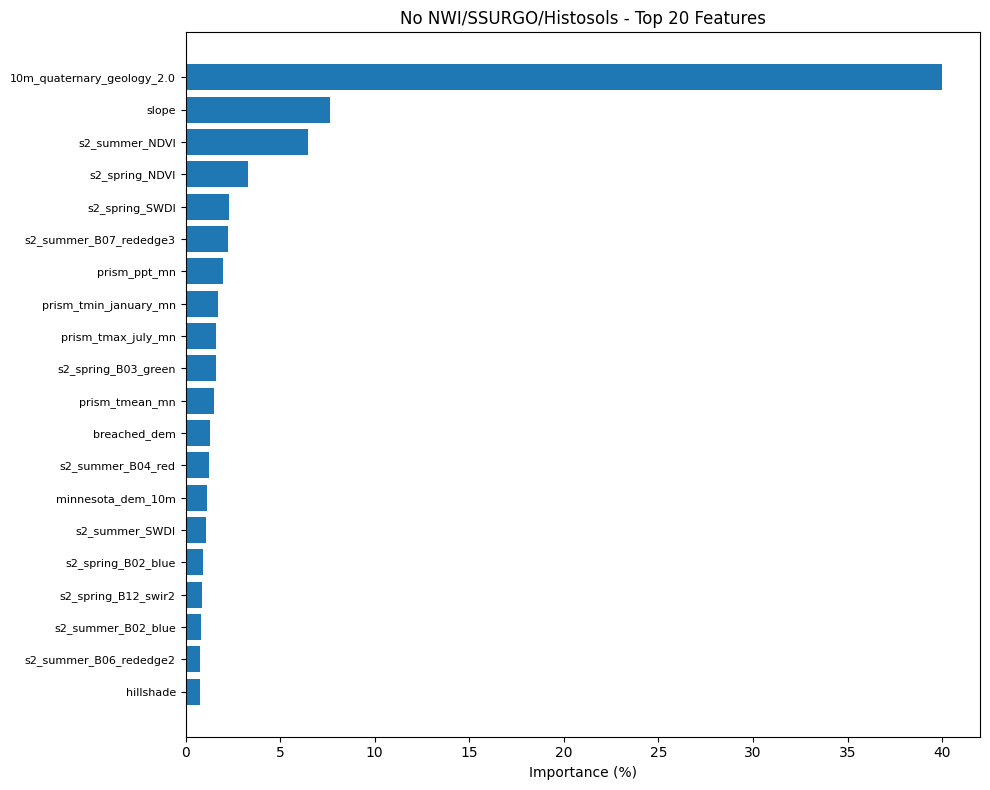

In [24]:
# Load one model for feature importance
with open(f'{MODEL_DIR}/model_fold_0.pkl', 'rb') as f:
    model = pickle.load(f)

# Get importances
importances = model.feature_importances_ * 100
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance (%)': importances
}).sort_values('Importance (%)', ascending=False)

importance_df['Importance (%)'] = importance_df['Importance (%)'].round(2)

# Save
importance_df.to_csv(f"{RESULTS_DIR}/feature_importance.csv", index=False)

# Display top 20
print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)
print(importance_df.head(20).to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
top20 = importance_df.head(20)
plt.barh(range(len(top20)), top20['Importance (%)'])
plt.yticks(range(len(top20)), top20['Feature'], fontsize=8)
plt.xlabel('Importance (%)')
plt.title(f'{EXP_NAME} - Top 20 Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
catalog_path = '/scratch.global/ocon0444/peat_modeling/MODEL_CATALOG.csv'

# Load existing catalog
try:
    catalog = pd.read_csv(catalog_path)
except FileNotFoundError:
    # Create new if doesn't exist
    catalog = pd.DataFrame(columns=[
        'exp_id', 'exp_name', 'model_type', 'target_variable', 'covariates_used',
        'nwi_included', 'ssurgo_included', 'n_features', 'n_samples',
        'cv_r2_mean', 'cv_r2_std', 'cv_rmse_mean', 'cv_mae_mean',
        'notebook_path', 'model_dir', 'prediction_dir', 'date_created', 'notes'
    ])

# Remove if exists
catalog = catalog[catalog['exp_id'] != EXP_ID]

# Create new entry
new_entry = {
    'exp_id': EXP_ID,
    'exp_name': EXP_NAME,
    'model_type': 'regression',
    'target_variable': 'depb',
    'covariates_used': 'terrain_climate_s2_geology_geomorphology',
    'nwi_included': False,
    'ssurgo_included': False,
    'n_features': len(feature_cols),
    'n_samples': len(df_clean),
    'cv_r2_mean': CV_R2_MEAN,
    'cv_r2_std': CV_R2_STD,
    'cv_rmse_mean': CV_RMSE_MEAN,
    'cv_mae_mean': CV_MAE_MEAN,
    'notebook_path': f'01_notebooks/depth_regression/{EXP_ID}_no_nwi_ssurgo_histosols.ipynb',
    'model_dir': MODEL_DIR,
    'prediction_dir': f'/scratch.global/ocon0444/peat_modeling/04_predictions/{EXP_ID}/',
    'date_created': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'notes': 'Excluding NWI, SSURGO, histosols, organic component to test prediction without direct peat-identifying layers (PI guidance point a)'
}

# Append and save
catalog = pd.concat([catalog, pd.DataFrame([new_entry])], ignore_index=True)
catalog.to_csv(catalog_path, index=False)

print("="*80)
print("ADDED TO MODEL CATALOG")
print("="*80)
print(f"Experiment ID: {EXP_ID}")
print(f"Catalog updated at: {catalog_path}")
print(f"\nEntry:")
for key, val in new_entry.items():
    if key not in ['notebook_path', 'model_dir', 'prediction_dir', 'notes']:
        print(f"  {key}: {val}")

ADDED TO MODEL CATALOG
Experiment ID: exp002
Catalog updated at: /scratch.global/ocon0444/peat_modeling/MODEL_CATALOG.csv

Entry:
  exp_id: exp002
  exp_name: No NWI/SSURGO/Histosols
  model_type: regression
  target_variable: depb
  covariates_used: terrain_climate_s2_geology_geomorphology
  nwi_included: False
  ssurgo_included: False
  n_features: 131
  n_samples: 12921
  cv_r2_mean: 0.6960243282456846
  cv_r2_std: 0.011087472544252422
  cv_rmse_mean: 77.00343695174271
  cv_mae_mean: 45.448132859573505
  date_created: 2026-02-13 14:20:26


In [26]:
print("\n" + "="*80)
print("EXPERIMENT COMPLETE")
print("="*80)
print(f"Experiment: {EXP_ID} - {EXP_NAME}")
print(f"\nExcluded peat-identifying layers:")
for keyword in exclude_keywords:
    print(f"  - {keyword}")
print(f"\nUsed {len(feature_cols)} features from:")
print(f"  - Terrain: {len(terrain_features)}")
print(f"  - Climate: {len(climate_features)}")
print(f"  - Sentinel-2: {len(s2_features)}")
print(f"  - Geology: {len(geology_features)}")
print(f"  - Geomorphology: {len(geomorph_features)}")
print(f"\nPerformance (all data):")
print(f"  R² = {CV_R2_MEAN:.4f} ± {CV_R2_STD:.4f}")
print(f"  RMSE = {CV_RMSE_MEAN:.2f} cm")
print(f"\nOutputs saved to:")
print(f"  Models: {MODEL_DIR}")
print(f"  Results: {RESULTS_DIR}")
print("="*80)


EXPERIMENT COMPLETE
Experiment: exp002 - No NWI/SSURGO/Histosols

Excluded peat-identifying layers:
  - MN_organic_soils_classified
  - gNATSGO
  - histosols
  - MN_ANY_organic_component
  - mn_nwi_cowardin

Used 131 features from:
  - Terrain: 15
  - Climate: 4
  - Sentinel-2: 36
  - Geology: 53
  - Geomorphology: 17

Performance (all data):
  R² = 0.6960 ± 0.0111
  RMSE = 77.00 cm

Outputs saved to:
  Models: /scratch.global/ocon0444/peat_modeling/03_models/exp002/
  Results: /scratch.global/ocon0444/peat_modeling/05_results/exp002/
